In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

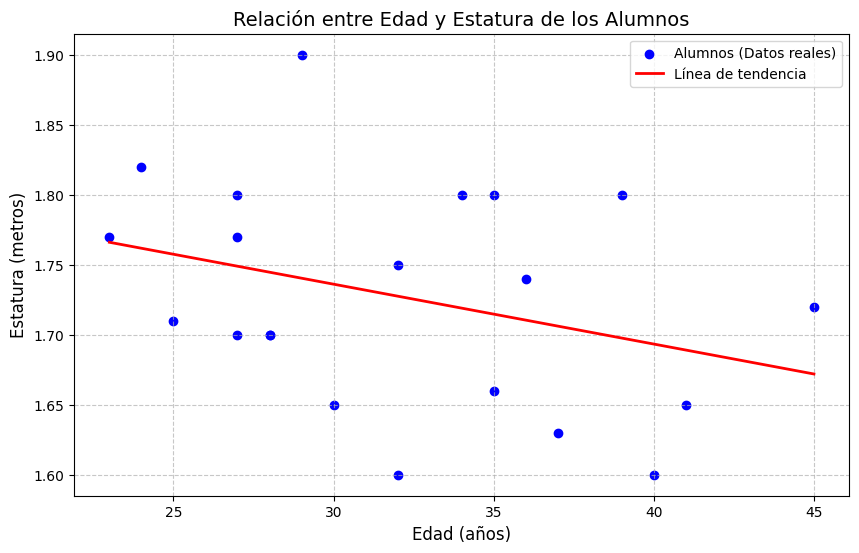

In [6]:
#Se extraen edades (X) y estaturas (Y)
edades = np.array([alumno[1] for alumno in lista_alumnos])
estaturas = np.array([alumno[2] for alumno in lista_alumnos])

#Se Calcula la línea de tendencia (Regresión lineal simple)
#polyfit devuelve la pendiente y el intercepto:
coeficientes = np.polyfit(edades, estaturas, 1) #"np.polyfit" encuentra la línea que mejor se ajusta a los puntos minimizando el error
linea_tendencia = np.poly1d(coeficientes)

#Se crea el gráfico:
plt.figure(figsize=(10, 6))

#Se dibujan los puntos de los alumnos:
plt.scatter(edades, estaturas, color='blue', label='Alumnos (Datos reales)') #"plt.scatter" dibuja los puntos individuales para que se vea la dispersión real

#Se dibuja la línea de relación:
x_rango = np.linspace(min(edades), max(edades), 100)
plt.plot(x_rango, linea_tendencia(x_rango), color='red', linewidth=2, label='Línea de tendencia') #"plt.scatter" dibuja los puntos individuales para que ver la dispersión real

#Personalización:
plt.title('Relación entre Edad y Estatura de los Alumnos', fontsize=14)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Estatura (metros)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#Mostrar resultado:
plt.show()

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [14]:
#Primero hay que hacer un análisis descriptivo para demostrarlo; para ello, hay que sacar los estadísticos descriptivos:
#Convertir a Dataframe de Pandas:
df = pd.DataFrame(lista_alumnos, columns=['Nombre', 'Edad', 'Estatura'])

#Generar estadísticos descriptivos:
#".describe()"" para obtener media, desviación, min, max y cuartiles
estadisticas = df[['Edad', 'Estatura']].describe()
print(estadisticas)

            Edad   Estatura
count  21.000000  21.000000
mean   32.095238   1.727143
std     6.081980   0.079003
min    23.000000   1.600000
25%    27.000000   1.660000
50%    32.000000   1.720000
75%    36.000000   1.800000
max    45.000000   1.900000


In [ ]:
#La edad en adultos y la estatura no suele estar relacionado linealmente, por lo que la regresión lineal no es muy útil:
#Se analizan los estadísticos descriptivos:
#"std" es desviación estandar y es de 0.079 m para la Altura, lo que indica que la mayoría están muy cerca del promedio (1.727 m), independientemente de su edad

#Visualización de la "Nube de Puntos": los puntos no forman una diagonal clara, sino que están dispersos
#Para que la técnica sea buena, los puntos deberían estar alineados sobre la línea roja
#Esta técnica sería perfecta si los sujetos fueran niños de 0 a 14 años (donde el crecimiento es lineal y constante)

In [23]:
df['Edad'].corr(df['Estatura'], method='pearson')

np.float64(-0.3292749795484255)

In [ ]:
#Análisis de Correlación: para saber si una línea es una buena técnica, usamos el Coeficiente de Correlación de Pearson (r): si es cercano a 1 o -1, la línea es una buena técnica
#Si es cercano a 0, no hay relación lineal y el modelo no servirá
#r=-0.33
#Conclusión del análisis: Existe una correlación negativa muy débil. Un valor de -0.33 indica que la edad solo explica una parte insignificante de la variación en la estatura 

### Entrena un modelo de regresión lineal

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [27]:
#Datos de la lista (X = Edad, y = Estatura):
X = np.array([24, 25, 35, 37, 29, 27, 28, 32, 36, 45, 41, 30, 40, 39, 23, 32, 27, 34, 27, 28, 35]).reshape(-1, 1)
y = np.array([1.82, 1.71, 1.66, 1.63, 1.90, 1.80, 1.70, 1.60, 1.74, 1.72, 1.65, 1.65, 1.60, 1.80, 1.77, 1.75, 1.70, 1.80, 1.77, 1.70, 1.80])

#Inicializar y entrenar el modelo:
modelo = LinearRegression()
modelo.fit(X, y)

#Realizar predicciones para comparar:
prediccion = modelo.predict(X)

#Parámetros obtenidos:
intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]
print(intercepto)
print(coeficiente)

1.8644194129763132
-0.00427716271884655


In [ ]:
#Resultados del Modelo:
#Tras el entrenamiento, el modelo ha generado la siguiente ecuación matemática: Estatura = 1.864 - (0.0043 * Edad)

#Intercepto (1.864): es el punto de partida teórico
#Coeficiente (-0.0043): indica que por cada año que cumple un alumno, el modelo predice que su estatura disminuye unos 2.9 milímetros

#Conclusión: el modelo ha sido entrenado correctamente, pero su capacidad predictiva es muy baja. En ciencia de datos, esto nos dice que la edad no es un buen predictor 
#de la estatura en una población adulta

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [ ]:
#Para entender qué tan "lejos" está la realidad de lo que predice el modelo, se calculan los residuos (la diferencia entre la estatura real y la predicha)
#Primero de forma manual (usando lógica pura de Python) y luego con la librería Scikit-Learn para validar

In [10]:
from sklearn import metrics

In [28]:
#Datos originales:
edades = np.array([24, 25, 35, 37, 29, 27, 28, 32, 36, 45, 41, 30, 40, 39, 23, 32, 27, 34, 27, 28, 35]).reshape(-1, 1)
estaturas_reales = np.array([1.82, 1.71, 1.66, 1.63, 1.90, 1.80, 1.70, 1.60, 1.74, 1.72, 1.65, 1.65, 1.60, 1.80, 1.77, 1.75, 1.70, 1.80, 1.77, 1.70, 1.80])

#Se entrena el modelo para obtener las predicciones:
modelo = LinearRegression().fit(edades, estaturas_reales)
predicciones = modelo.predict(edades)

# --- CÁLCULO MANUAL ---
errores = estaturas_reales - predicciones  # Diferencia individual
mae_manual = np.mean(np.abs(errores))      # Promedio de errores absolutos
mse_manual = np.mean(errores**2)           # Promedio de errores al cuadrado
rmse_manual = np.sqrt(mse_manual)          # Raíz del MSE
mape_manual = np.mean(np.abs(errores / estaturas_reales)) * 100

# --- CÁLCULO CON SKLEARN ---
mae = metrics.mean_absolute_error(estaturas_reales, predicciones)
mse = metrics.mean_squared_error(estaturas_reales, predicciones)
rmse = np.sqrt(mse)
mape = metrics.mean_absolute_percentage_error(estaturas_reales, predicciones) * 100

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  0.0631
MSE:  0.0053
RMSE: 0.0728
MAPE: 3.66%


In [ ]:
#Interpretación de los resultados:
# MAE (Error Absoluto Medio): 0.0631
# Significado: En promedio, el modelo se equivoca por 6.31 centímetros
# MSE (Error Cuadrático Medio): 0.0053
# Significado: Al elevar los errores al cuadrado, se castigan más las desviaciones grandes
# RMSE (Raíz del Error Cuadrático Medio): 0.0728
# Significado: Es la desviación estándar de los errores. Nos dice que el error típico es de casi 8 centímetros. Al ser mayor que el MAE, indica que hay algunos alumnos cuyas
# estaturas están muy lejos de la línea (valores atípicos)
# MAPE (Error Porcentual Absoluto Medio): 3.66%
# Significado: El error relativo es del 3.66% respecto a la estatura real. Aunque parece un porcentaje pequeño, 
# en estaturas humanas 8 cm es la diferencia entre alguien de estatura media y alguien muy alto

# ¿Qué error se está cometiendo realmente?
# El error es de subajuste (underfitting). El modelo es demasiado simple (una línea recta) para explicar un fenómeno complejo donde la edad no es el factor determinante. 
# La "línea" simplemente intenta pasar por el medio de todos, pero no logra "explicar" a nadie con precisión.